# ek_envelope_eda
Channels 14, 21, 29 — lower envelope EDA · rolling min · periodicity · residual scoring

In [114]:
%%script true
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/Colab Notebooks/sentinel
!pip install -e .

import sys
sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/sentinel/src")

In [115]:
%%script true
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import uniform_filter1d

from sentinel.ml_logic.metrics import compute_all_metrics, event_f05
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.data import find_anomaly_segments

ANOMALY_COLOR = '#e74c3c'
NOMINAL_COLOR = '#2980b9'

In [116]:
# ── config ────────────────────────────────────────────────────────────────────
CHANNELS   = ['channel_14', 'channel_21', 'channel_29']
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

ENV_WINDOW = 300     # rolling min window for lower envelope
MA_WINDOW  = 5_000   # MA window for envelope baseline (tune after Viz 3)
SHOW_N     = 1_000_000  # rows shown in overview plots

RAW_DIR = Path('./data/raw')
SUB_DIR = Path('./submissions')
SUB_DIR.mkdir(exist_ok=True)

In [117]:
cols  = ['id', 'is_anomaly'] + CHANNELS
train = pq.read_table(str(RAW_DIR / 'train.parquet'), columns=cols
                      ).to_pandas().set_index('id')
test  = pq.read_table(str(RAW_DIR / 'test.parquet'),
                      columns=['id'] + CHANNELS).to_pandas().set_index('id')
print(f'Train: {len(train):,} rows  |  Test: {len(test):,} rows')
print(train[CHANNELS].describe().round(3))

Train: 14,728,321 rows  |  Test: 521,280 rows
         channel_14    channel_21    channel_29
count  1.472832e+07  1.472832e+07  1.472832e+07
mean   2.720000e-01  2.780000e-01  2.910000e-01
std    9.500000e-02  9.800000e-02  9.100000e-02
min    7.800000e-02  7.400000e-02  8.600000e-02
25%    2.140000e-01  2.190000e-01  2.350000e-01
50%    2.590000e-01  2.660000e-01  2.820000e-01
75%    3.060000e-01  3.140000e-01  3.250000e-01
max    9.710000e-01  1.000000e+00  9.710000e-01


In [118]:
n       = len(train)
tr_end  = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

X_tr       = train[CHANNELS].iloc[:tr_end]
X_val      = train[CHANNELS].iloc[tr_end:val_end]
X_test_int = train[CHANNELS].iloc[val_end:]
y_tr       = train['is_anomaly'].values[:tr_end]
y_val      = train['is_anomaly'].values[tr_end:val_end]
y_test_int = train['is_anomaly'].values[val_end:]
print(f'Train: {len(X_tr):,} | Val: {len(X_val):,} | Test_int: {len(X_test_int):,}')
print(f'Val anomaly rate: {y_val.mean():.4%}  |  Test_int: {y_test_int.mean():.4%}')

Train: 10,309,824 | Val: 2,209,248 | Test_int: 2,209,249
Val anomaly rate: 10.1136%  |  Test_int: 10.7724%


In [119]:
def rolling_min_envelope(arr, window):
    """Causal rolling minimum — lower envelope."""
    return pd.Series(arr).rolling(window=window, min_periods=1).min().values

def envelope_residual(arr, env_window, ma_window):
    """env = rolling_min(arr, env_window);  return env - centered_MA(env, ma_window)."""
    env = rolling_min_envelope(arr, env_window)
    ma  = pd.Series(env).rolling(window=ma_window, min_periods=1, center=True).mean().values
    return env, ma, env - ma

## Viz 1 — Raw signal overview

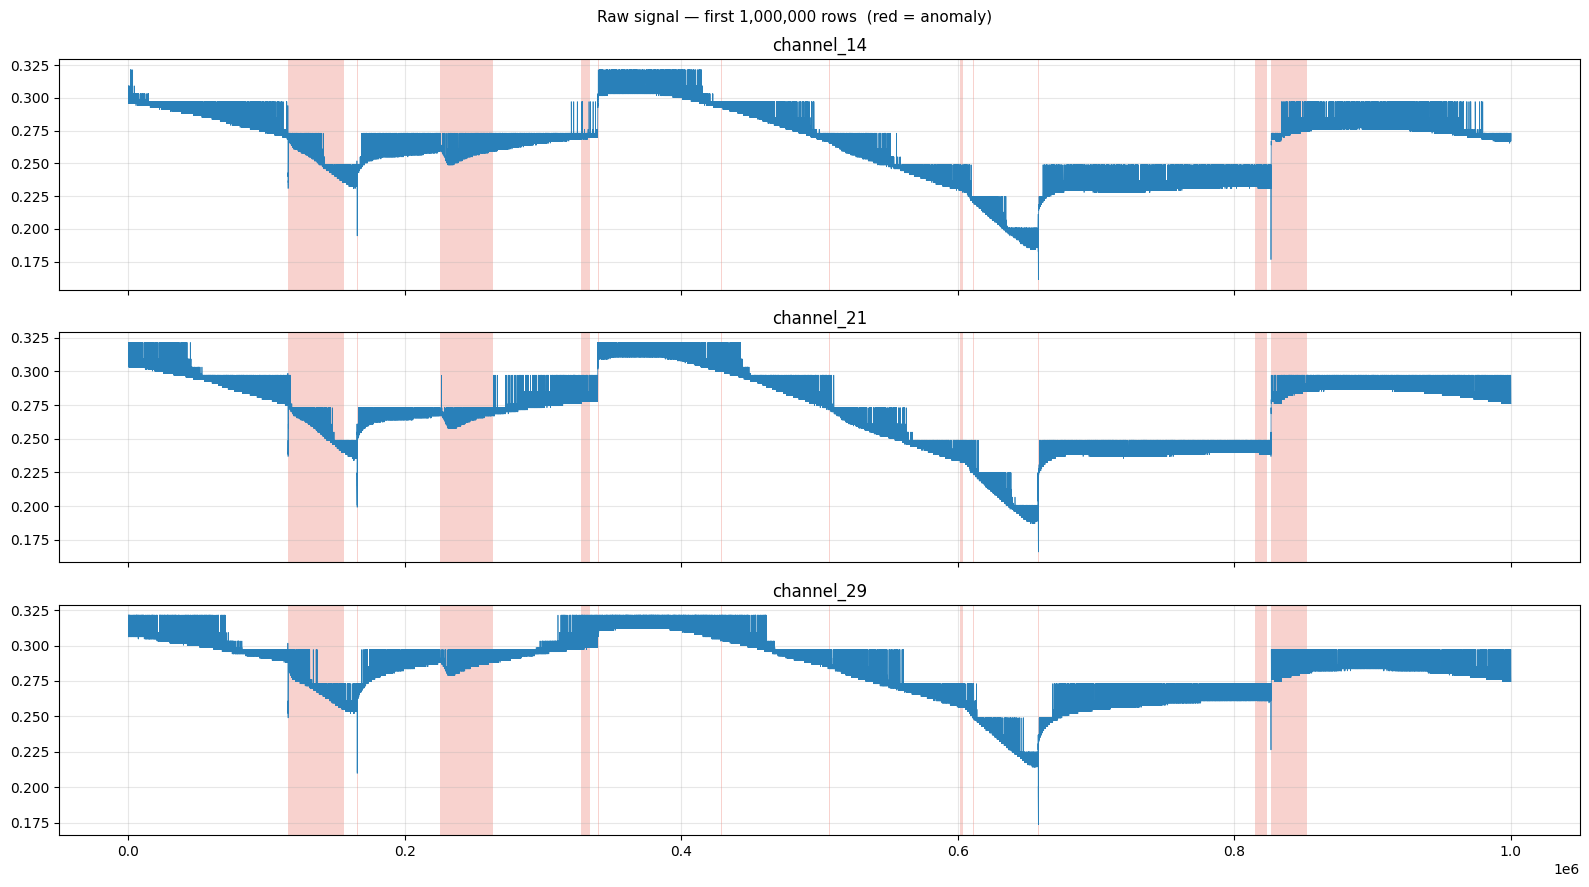

In [120]:
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(16, 3 * len(CHANNELS)), sharex=True)
anom_segs = find_anomaly_segments(train['is_anomaly'].values[:SHOW_N])
for ax, ch in zip(axes, CHANNELS):
    ax.plot(train[ch].values[:SHOW_N], lw=0.5, color=NOMINAL_COLOR)
    for seg in anom_segs:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.25, linewidth=0)
    ax.set_title(ch);  ax.grid(True, alpha=0.3)
plt.suptitle(f'Raw signal — first {SHOW_N:,} rows  (red = anomaly)', fontsize=11)
plt.tight_layout();  plt.show()

## Viz 2 — Raw + lower envelope (rolling min)

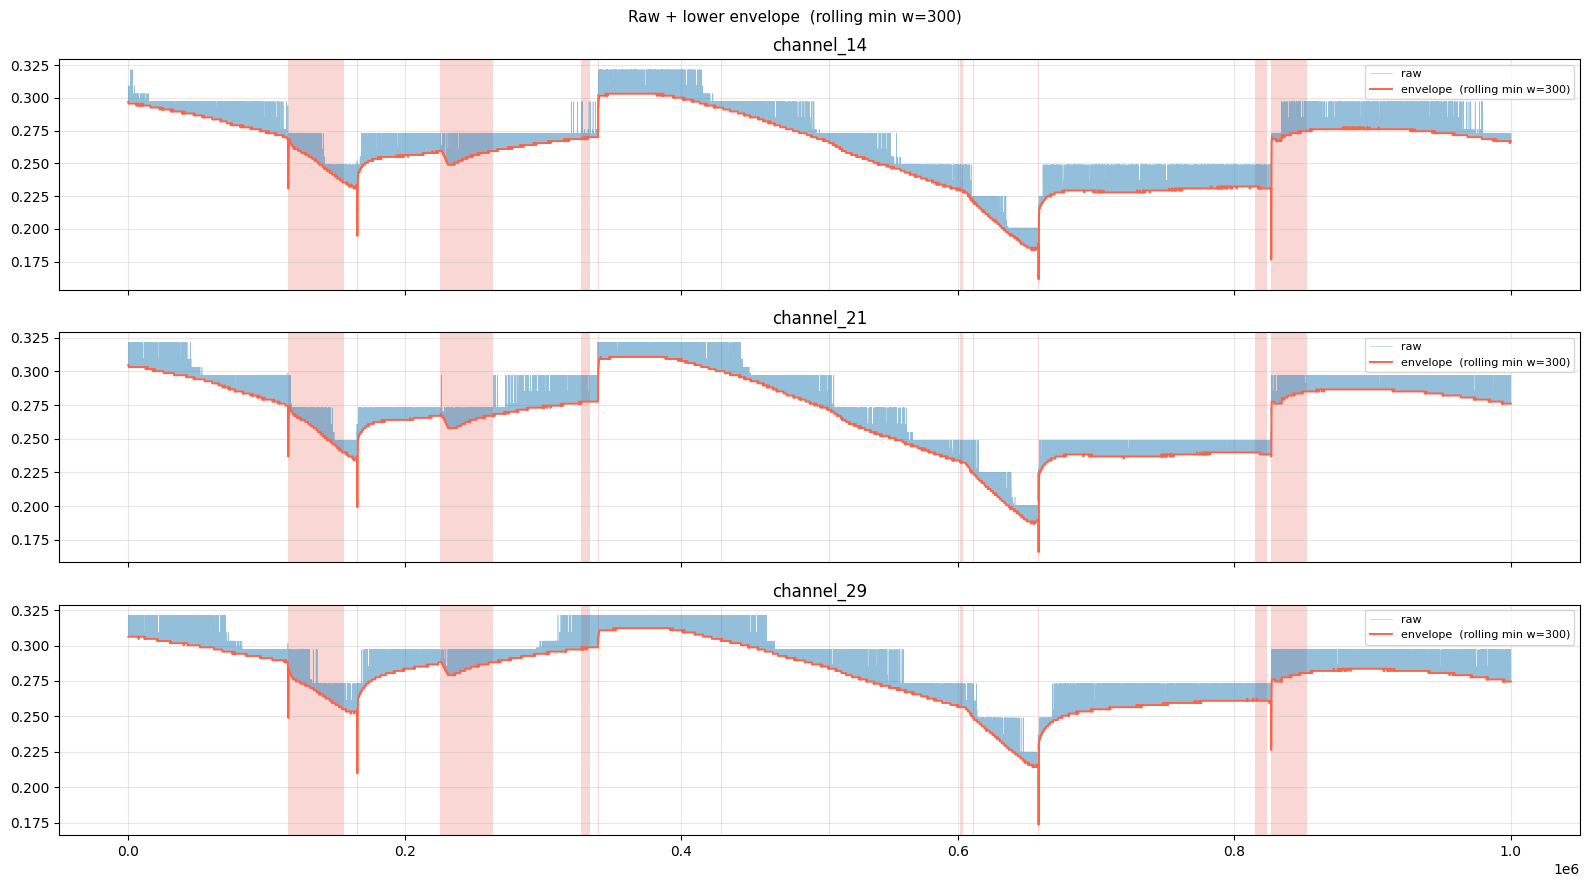

In [121]:
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(16, 3 * len(CHANNELS)), sharex=True)
anom_segs = find_anomaly_segments(train['is_anomaly'].values[:SHOW_N])
for ax, ch in zip(axes, CHANNELS):
    raw = train[ch].values[:SHOW_N]
    env = rolling_min_envelope(raw, ENV_WINDOW)
    ax.plot(raw, lw=0.4, alpha=0.5, color=NOMINAL_COLOR, label='raw')
    ax.plot(env, lw=1.4, color='tomato', label=f'envelope  (rolling min w={ENV_WINDOW})')
    for seg in anom_segs:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.22, linewidth=0)
    ax.set_title(ch);  ax.legend(fontsize=8, loc='upper right');  ax.grid(True, alpha=0.3)
plt.suptitle(f'Raw + lower envelope  (rolling min w={ENV_WINDOW})', fontsize=11)
plt.tight_layout();  plt.show()

## Viz 4 — Envelope residual  (env − MA)
After setting `MA_WINDOW` above: anomalies should appear as sharp negative spikes in the residual.

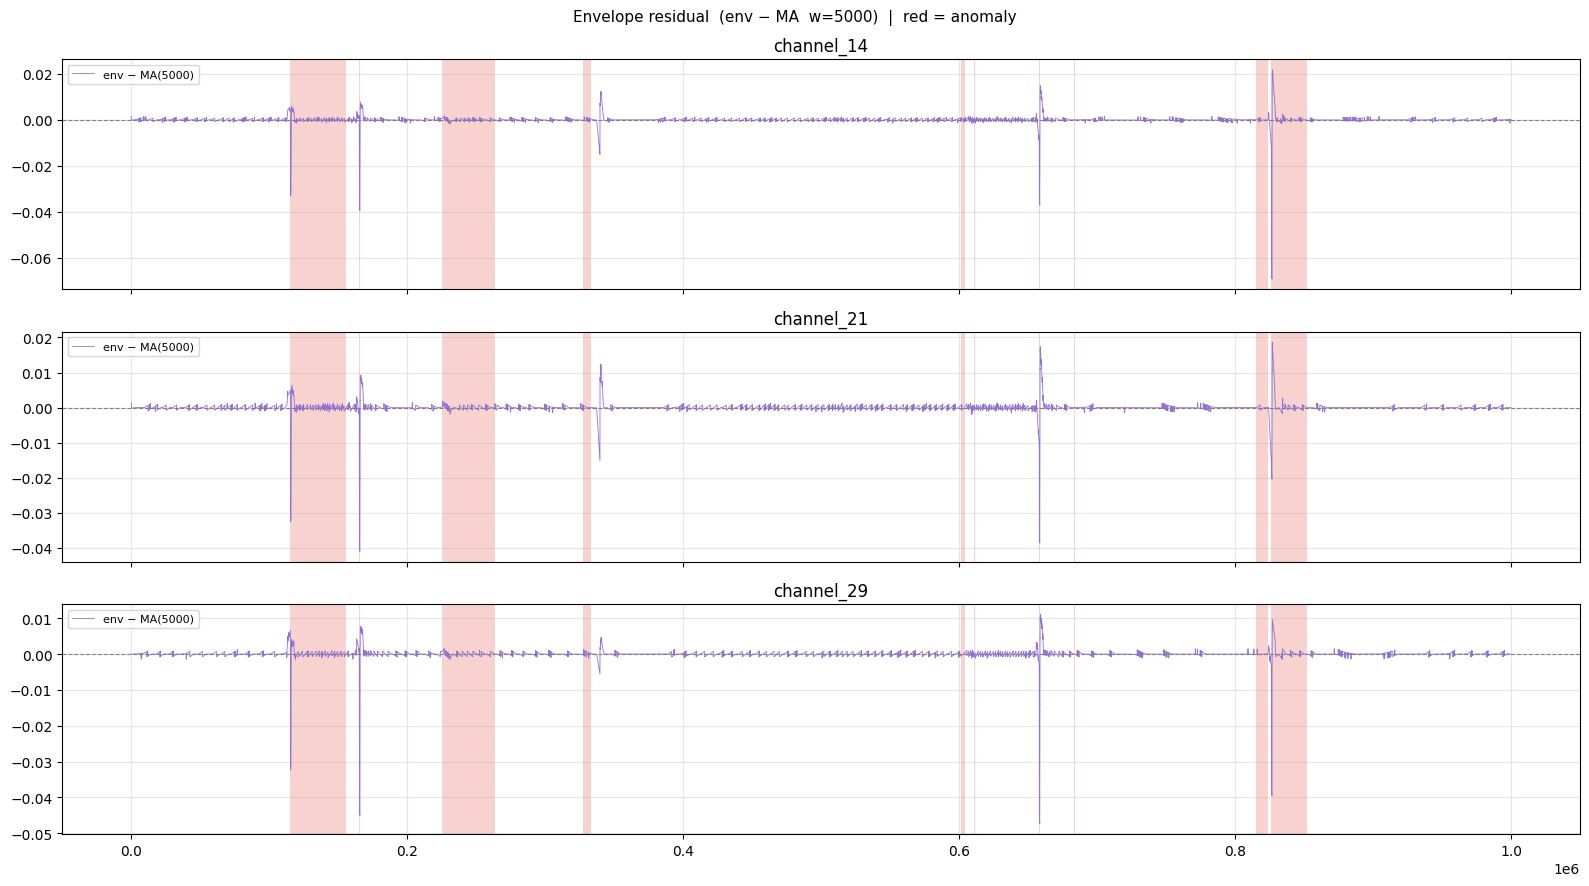

In [122]:
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(16, 3 * len(CHANNELS)), sharex=True)
anom_segs = find_anomaly_segments(train['is_anomaly'].values[:SHOW_N])
for ax, ch in zip(axes, CHANNELS):
    raw = train[ch].values[:SHOW_N]
    env, ma, res = envelope_residual(raw, ENV_WINDOW, MA_WINDOW)
    ax.plot(res, lw=0.6, color='mediumpurple', label=f'env − MA({MA_WINDOW})')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    for seg in anom_segs:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.25, linewidth=0)
    ax.set_title(ch);  ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)
plt.suptitle(f'Envelope residual  (env − MA  w={MA_WINDOW})  |  red = anomaly', fontsize=11)
plt.tight_layout();  plt.show()

## Viz 5 — Envelope + MA overlay
Check that MA tracks the slow trend without swallowing anomaly dips.

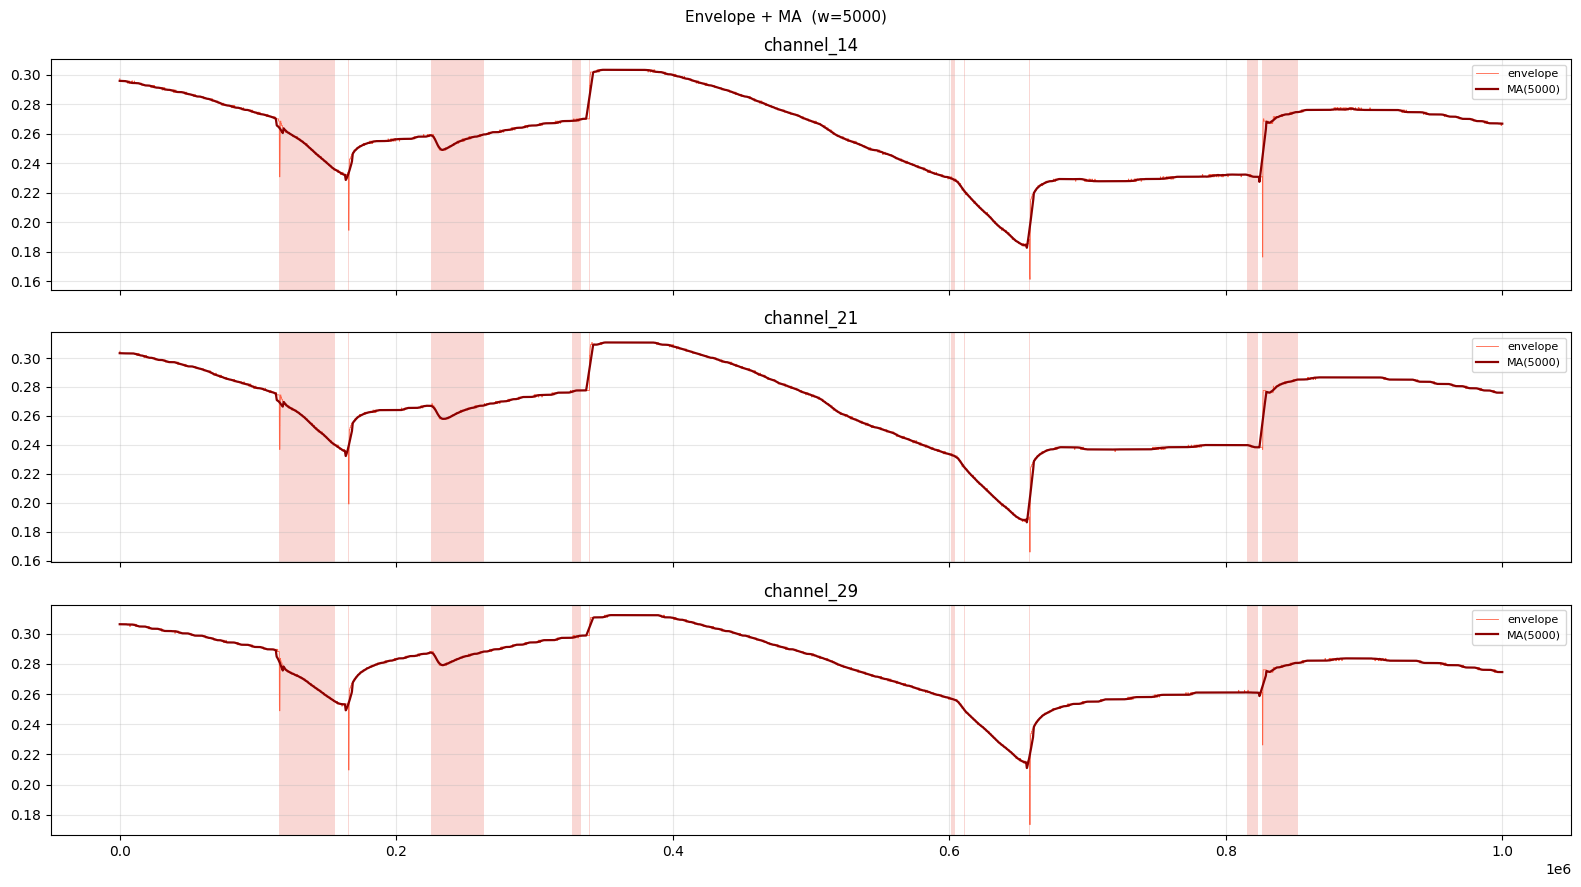

In [123]:
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(16, 3 * len(CHANNELS)), sharex=True)
anom_segs = find_anomaly_segments(train['is_anomaly'].values[:SHOW_N])
for ax, ch in zip(axes, CHANNELS):
    raw = train[ch].values[:SHOW_N]
    env, ma, _ = envelope_residual(raw, ENV_WINDOW, MA_WINDOW)
    ax.plot(env, lw=0.6, color='tomato',   label='envelope')
    ax.plot(ma,  lw=1.6, color='darkred',  label=f'MA({MA_WINDOW})')
    for seg in anom_segs:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.22, linewidth=0)
    ax.set_title(ch);  ax.legend(fontsize=8, loc='upper right');  ax.grid(True, alpha=0.3)
plt.suptitle(f'Envelope + MA  (w={MA_WINDOW})', fontsize=11)
plt.tight_layout();  plt.show()

## Rolling Z-score scoring
`env_residual → rolling z-score(ZSCORE_WINDOW) → top_p_mean → tune_threshold`  
Параметры для подбора: `ENV_WINDOW`, `MA_WINDOW`, `ZSCORE_WINDOW` в config.

In [124]:
def rolling_zscore(df, window):
    """Causal per-channel rolling Z-score."""
    roll = df.rolling(window=window, min_periods=max(2, window // 10))
    mu   = roll.mean()
    sd   = roll.std().fillna(1.0).clip(lower=1e-8)
    return ((df - mu) / sd).fillna(0.0)

def top_p_mean(z_arr, p):
    """Mean of top-p fraction of channels by |z|."""
    n_top = max(1, int(z_arr.shape[1] * p))
    top   = np.partition(np.abs(z_arr), -n_top, axis=1)[:, -n_top:]
    return top.mean(axis=1)

def split_tp_fn(y_true, y_pred):
    true_segs = find_anomaly_segments(y_true)
    pred_segs = find_anomaly_segments(y_pred)
    tp, fn = [], []
    for ts in true_segs:
        hit = any(ps['end'] >= ts['start'] and ps['start'] <= ts['end']
                  for ps in pred_segs)
        (tp if hit else fn).append(ts)
    return tp, fn

In [125]:
# Re-run this cell when ENV_WINDOW / MA_WINDOW
print('Computing envelope residuals …')
envr_cols = []
for ch in CHANNELS:
    col = ch + '_envr'
    _, _, res = envelope_residual(train[ch].values, ENV_WINDOW, MA_WINDOW)
    train[col] = res
    envr_cols.append(col)

Computing envelope residuals …


In [126]:
## Viz 6 — Rolling Z-score per channel

Rolling z-score  window=50000 …
Done.


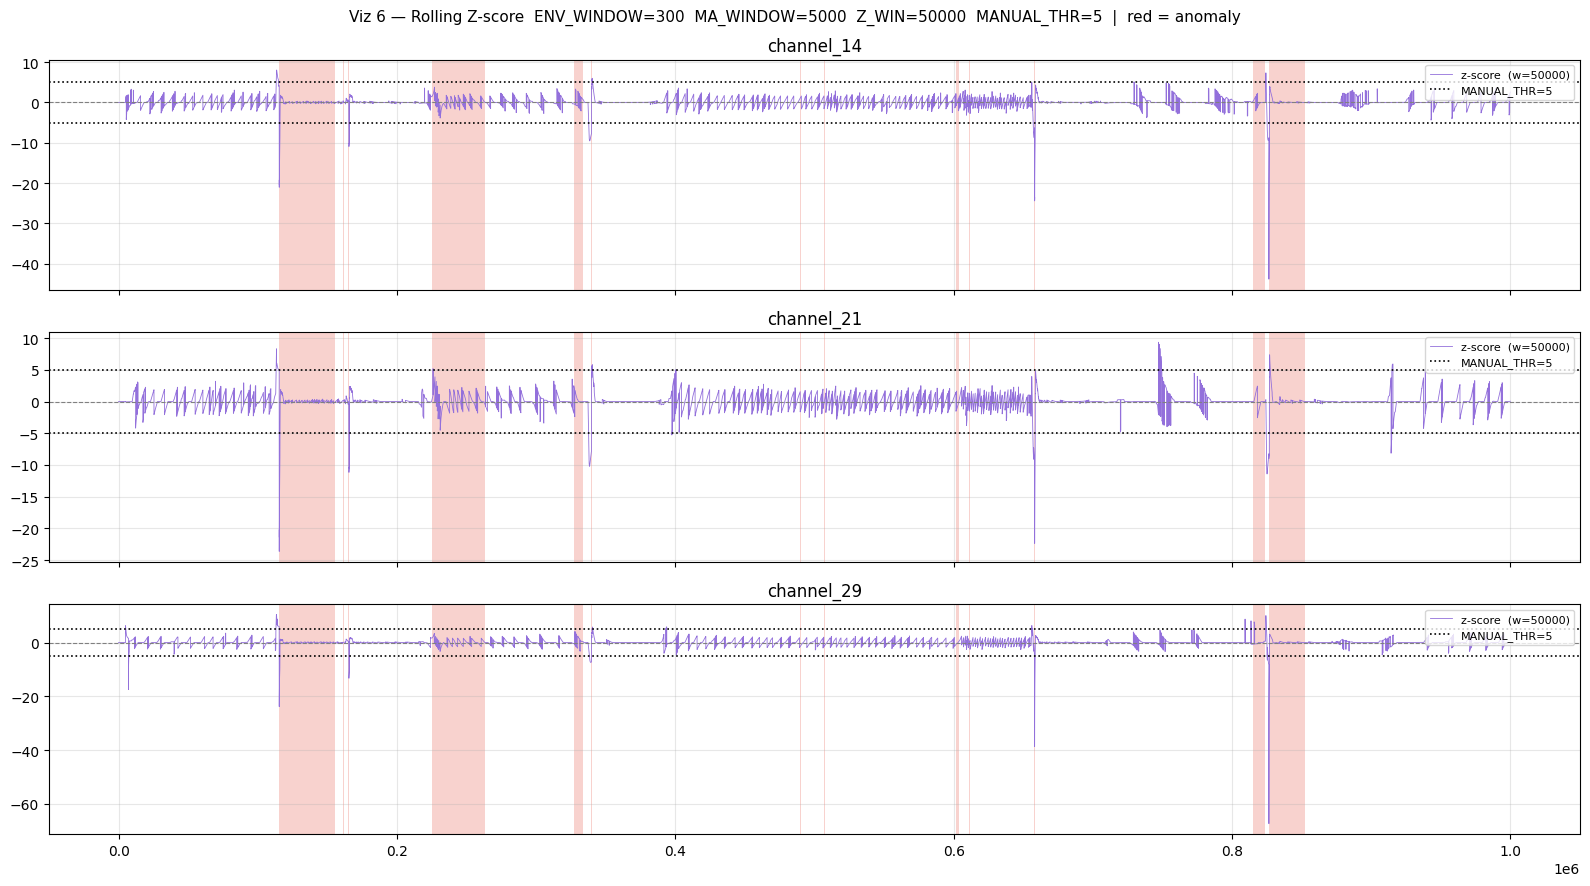

In [138]:
ZSCORE_WINDOW = 50000

# ── Compute envelope residuals + rolling z-score ──────────────────────────────
# Re-run this cell when ZSCORE_WINDOW change.
print(f'Rolling z-score  window={ZSCORE_WINDOW} …')
z_full     = rolling_zscore(train[envr_cols], ZSCORE_WINDOW)
#std_tr = train[envr_cols].iloc[:tr_end].std()
#z_full = (train[envr_cols] - 0) / std_tr
z_val      = z_full.iloc[tr_end:val_end]
z_test_int = z_full.iloc[val_end:]
print('Done.')
# Re-run after changing ENV_WINDOW / MA_WINDOW / ZSCORE_WINDOW / MANUAL_THR in config.
MANUAL_THR = 5
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(16, 3 * len(CHANNELS)), sharex=True)
anom_segs = find_anomaly_segments(train['is_anomaly'].values[:SHOW_N])
for ax, ch in zip(axes, CHANNELS):
    zs = z_full[ch + '_envr'].values[:SHOW_N]
    ax.plot(zs, lw=0.6, color='mediumpurple', label=f'z-score  (w={ZSCORE_WINDOW})')
    ax.axhline(0,           color='gray',  lw=0.8, ls='--')
    ax.axhline( MANUAL_THR, color='black', lw=1.2, ls=':', label=f'MANUAL_THR={MANUAL_THR}')
    ax.axhline(-MANUAL_THR, color='black', lw=1.2, ls=':')
    for seg in anom_segs:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.25, linewidth=0)
    ax.set_title(ch);  ax.legend(fontsize=8, loc='upper right');  ax.grid(True, alpha=0.3)
plt.suptitle(
    f'Viz 6 — Rolling Z-score  '
    f'ENV_WINDOW={ENV_WINDOW}  MA_WINDOW={MA_WINDOW}  Z_WIN={ZSCORE_WINDOW}  '
    f'MANUAL_THR={MANUAL_THR}  |  red = anomaly',
    fontsize=11)
plt.tight_layout();  plt.show()

In [137]:
#%%script true
# ── [Slow] Grid search: p × threshold ────────────────────────────────────────
# Run only when parameters are fixed and you want to find the optimal threshold.
# ─────────────────────────────────────────────────────────────────────────────
print(f'{"p":>6}  {"F0.5":>7}  {"thr":>10}')
print('-' * 30)
best_score, best_p, best_thr = -1, None, None

P_GRID        = [0.17, 0.33, 0.5, 0.67, 1.0]
for p in P_GRID:
    scores_val_p = top_p_mean(z_val.values, p=p)
    res = tune_threshold(scores_val_p, y_val, metric_fn=event_f05,
                         lo_percentile=(0, 90), hi_percentile=(1, 99.99), n_sweep=200)
    print(f'{p:>6.2f}  {res["score"]:>7.4f}  {res["threshold"]:>10.4g}')
    if res['score'] > best_score:
        best_score, best_p, best_thr = res['score'], p, res['threshold']

print(f'\nBest  p={best_p}  threshold={best_thr:.4g}  F0.5={best_score:.4f}')

     p     F0.5         thr
------------------------------
  0.17   0.7051       3.724
  0.33   0.7051       3.724
  0.50   0.7051       3.724
  0.67   0.7051       3.377
  1.00   0.7051       1.911

Best  p=0.17  threshold=3.724  F0.5=0.7051


── Validation metrics ─────────────────────────────
  event_f05                    0.705128
  event_f1                     0.564103
  event_f2                     0.470085
  event_precision              0.846154
  event_recall                 0.423077
  esa_f05                      0.702491
  esa_precision                0.841416
  esa_recall                   0.423077
  esa_tnr                      0.9944
  event_detection_rate         0.423077
  tp_events                    11
  n_events                     26
  fp_pred_events               2
  pa_f1                        0.719886
  pa_precision                 0.922251
  pa_recall                    0.590349
  row_precision                0.492492
  row_recall                   0.048296
  row_f1                       0.087966

── Internal test metrics ──────────────────────────
  event_f05                    0.666667
  event_f1                     0.444444
  event_f2                     0.333333
  event_precision              1.0
 

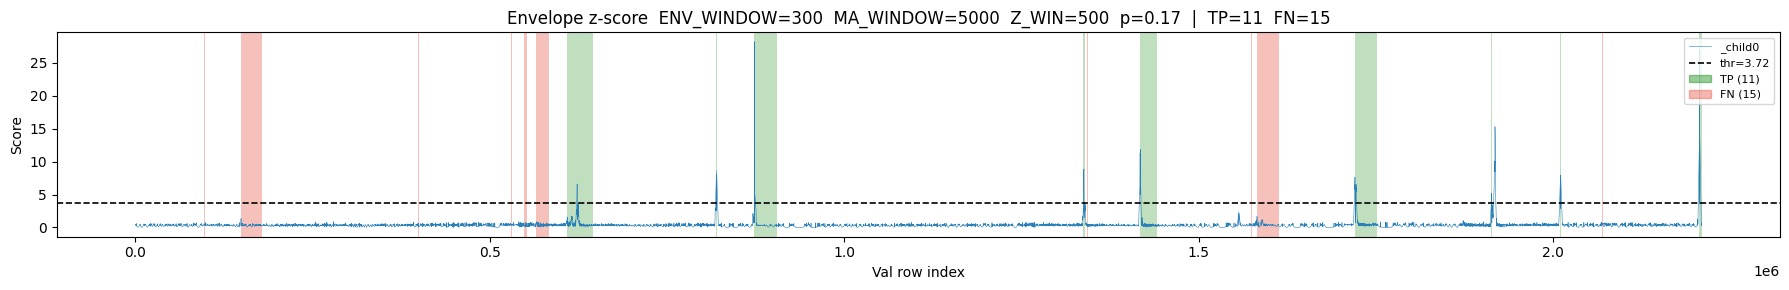

In [131]:
#%%script true
scores_val = top_p_mean(z_val.values, p=best_p)
y_pred_val = (scores_val > best_thr).astype(np.int8)

metrics = compute_all_metrics(y_val, y_pred_val)
print('── Validation metrics ─────────────────────────────')
for k, v in metrics.items():
    print(f'  {k:<28} {v}')

tp_events, fn_events = split_tp_fn(y_val, y_pred_val)

# ── Internal test ─────────────────────────────────────────────────────────────
scores_test_int = top_p_mean(z_test_int.values, p=best_p)
y_pred_test_int = (scores_test_int > best_thr).astype(np.int8)
metrics_ti = compute_all_metrics(y_test_int, y_pred_test_int)
print('\n── Internal test metrics ──────────────────────────')
for k, v in metrics_ti.items():
    print(f'  {k:<28} {v}')

# ── Score timeline ────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
step = max(1, len(scores_val) // 50_000)
idx  = np.arange(0, len(scores_val), step)
fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(idx, scores_val[idx], lw=0.4, color=NOMINAL_COLOR)
ax.axhline(best_thr, color='black', lw=1.2, ls='--', label=f'thr={best_thr:.3g}')
for ev in tp_events:
    ax.axvspan(ev['start'], ev['end'], color='green', alpha=0.25, linewidth=0)
for ev in fn_events:
    ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.35, linewidth=0)
ax.legend(handles=[
    ax.lines[0], ax.lines[1],
    mpatches.Patch(color='green',        alpha=0.4, label=f'TP ({len(tp_events)})'),
    mpatches.Patch(color=ANOMALY_COLOR,  alpha=0.4, label=f'FN ({len(fn_events)})'),
], fontsize=8, loc='upper right')
ax.set_xlabel('Val row index');  ax.set_ylabel('Score')
ax.set_title(f'Envelope z-score  ENV_WINDOW={ENV_WINDOW}  MA_WINDOW={MA_WINDOW}  '
             f'Z_WIN={ZSCORE_WINDOW}  p={best_p}  |  TP={len(tp_events)}  FN={len(fn_events)}')
plt.tight_layout();  plt.show()